<a href="https://colab.research.google.com/github/Akshaya24555/CodSoft/blob/main/exp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>EXPERIMENT 7</centeer>

<center>SENTIMENT ANALYSIS ON TWITTER DATASET USING RNN
</center>

AIM:

To implement a Recurrent Neural Network (RNN) for performing sentiment analysis on Twitter data and classify tweets into
Negative, Neutral, and Positive sentiments.

PRE-REQUISITES:
1. Basics of Machine Learning
2. Python Programming
3. Knowledge on Numpy, Pandas, Matplotlib, TensorFlow/ Keras
4. Jupyter Notebook
5. Data Pre-Processing Techniques
6. Knowledge on Neural Networks

**Twitter Dataset**


* The dataset has three sentiments namely, negative(-1), neutral(0), and positive(+1). It contains two fields for the tweet
and label.


* Download the Dataset - https://www.kaggle.com/datasets/saurabhshahane/twitter-sentiment-dataset/data

**1. Importing the Basic Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**2. Load the Dataset**

In [ ]:
df = pd.read_csv('/content/archive (1).zip')
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [ ]:
# Find any missing values
df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [ ]:
 #Removing Null Values
df = df.dropna()

**3. Pre-Process the Dataset**

In [ ]:
# Import the Required Libraries
import re


**a) Clean Tweet Text**


In [ ]:
def tweets_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text
df['clean_text'] = df['text'].apply(tweets_clean)

**b) Encode Sentiment Labels**

In [ ]:
# Import Label Encoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['category'] = label_encoder.fit_transform(df['sentiment'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
 4   clean_text     27480 non-null  object
 5   category       27480 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 1.5+ MB


In [ ]:
from tensorflow.keras.utils import to_categorical
# Create a target variable
# Label mapping becomes: Negative = 0, Neutral = 1, Positive = 2
y = to_categorical(df['category'], num_classes=3)

In [ ]:
df['category'].value_counts()

,count
category,
1,11117
2,8582
0,7781


**c) Apply Tokenization & Generate Numerical Sequences**

In [ ]:
# Import Libraries
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
df.head()

,textID,text,selected_text,sentiment,clean_text,category
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,id have responded if i were going,1
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,sooo sad i will miss you here in san diego,0
2,088c60f138,my boss is bullying me...,bullying me,negative,my boss is bullying me,0
3,9642c003ef,what interview! leave me alone,leave me alone,negative,what interview leave me alone,0
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,sons of why couldnt they put them on the rel...,0


In [ ]:
tokenizer = Tokenizer(num_words=1000)
tokenizer.fit_on_texts(df['clean_text'])

In [ ]:
# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])



**d) Apply Padding**

In [ ]:
# Import Libraires
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_length = 100
X = pad_sequences(sequences, maxlen=max_length)

**4. Split Data into Training & Testing Sets**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=56)

In [ ]:
# Sizes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((21984, 100), (5496, 100), (21984, 3), (5496, 3))

**5. Build the RNN Model**

In [ ]:
# Import the required Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

In [ ]:

# Build the Model
model = Sequential()
model.add(Embedding(input_dim=1001, output_dim=156))
model.add(SimpleRNN(34, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))

In [ ]:
# Compile the Model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

**6. Train the Model**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
# Train the Model
history = model.fit(X_train, y_train, epochs=6, batch_size=34, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/6
647/647 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4906 - loss: 1.0004 - val_accuracy: 0.6794 - val_loss: 0.7588
Epoch 2/6
647/647 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7010 - loss: 0.7301 - val_accuracy: 0.6683 - val_loss: 0.7603
Epoch 3/6
647/647 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.7228 - loss: 0.6873 - val_accuracy: 0.6910 - val_loss: 0.7268
Epoch 4/6
647/647 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.7421 - loss: 0.6415 - val_accuracy: 0.6938 - val_loss: 0.7369
Epoch 5/6
647/647 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.7449 - loss: 0.6266 - val_accuracy: 0.6840 - val_loss: 0.7463
Epoch 6/6
647/647 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.7568 - loss: 0.5946 - val_accuracy: 0.6945 - val_loss: 0.7370


**7. Evaluate the Model Performance**

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6878 - loss: 0.7248


In [ ]:
loss, accuracy

(0.7267876863479614, 0.6910480260848999)

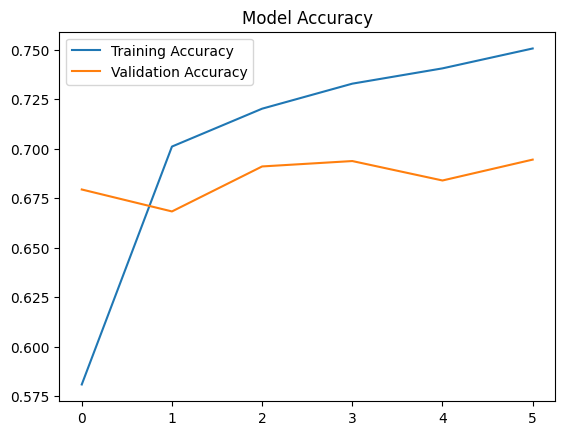

In [ ]:
# Accuracy Plots
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

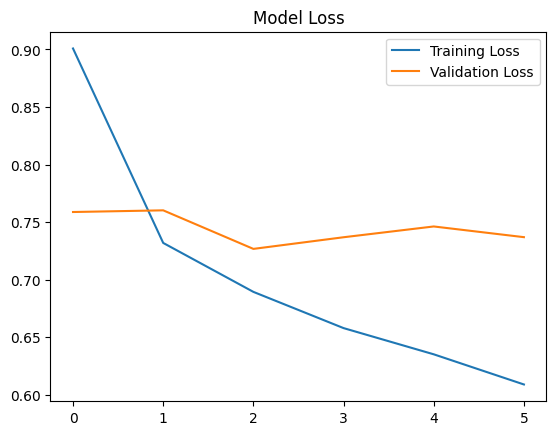

In [ ]:
# Loss Plots
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()


In [ ]:
# Print the Classification Report
from sklearn.metrics import classification_report
# Predict on test data
y_pred_prob = model.predict(X_test)
# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
# Convert one-hot encoded y_test to class labels
y_true = np.argmax(y_test, axis=1)

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.58      0.64      1574
           1       0.63      0.72      0.67      2214
           2       0.77      0.75      0.76      1708

    accuracy                           0.69      5496
   macro avg       0.70      0.69      0.69      5496
weighted avg       0.70      0.69      0.69      5496



**8. Generate New Predictions for new Tweets**

In [ ]:
# Create a new function to process the new tweet
def predict_sentiment(tweet):
    tweet = tweets_clean(tweet)
    seq = tokenizer.texts_to_sequences([tweet])
    padded = pad_sequences(seq, maxlen=max_length)
    pred = model.predict(padded)
    label = np.argmax(pred)
    if label == 0:
        return "Negative"
    elif label == 1:
        return "Neutral"
    else:
        return "Positive"

In [ ]:
predict_sentiment("This new G.O ruins the students life")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


'Neutral'

In [ ]:
predict_sentiment("I`d have responded, if I were going")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


'Neutral'

**RESULT:**

Sentiment analysis on Twitter data was successfully implemented using a Recurrent Neural Network (RNN). The model was
trained to classify tweets into Negative, Neutral, and Positive sentiments.